In [1]:
from jpegsplit.decode import decode_scan, parse_jpeg
from jpegsplit.encode import (
    clone_tables,
    encode_scan,
    ensure_tile_dc_huffman,
    make_tile_header,
    rebuild_tile_jpeg,
    )
from pathlib import Path
from jpegsplit.split import crop_tile_blocks, round_tile_size, tile_mcu_indices, tile_dims
import numpy as np
import os

In [2]:
in_path, out_prefix = "./test_images/M31.jpg", "./output/output"
os.makedirs(os.path.dirname(out_prefix), exist_ok=True)
tile_size = 512

data = Path(in_path).read_bytes()
_, _, header, scan, sof, sos, tables, dri = parse_jpeg(data)
blocks = decode_scan(scan, sof, sos, tables, dri)
tiles, tiles_x, tiles_y, mcu_w, mcu_h = tile_mcu_indices(sof, tile_size)
tile_sizes = tile_dims(sof, tile_size)
rounded_tile_size = round_tile_size(tile_size)
tile_step_x = ((rounded_tile_size + mcu_w - 1) // mcu_w) * mcu_w
tile_step_y = ((rounded_tile_size + mcu_h - 1) // mcu_h) * mcu_h
outputs = []
for idx, tile_ids in enumerate(tiles):
    new_w, new_h = tile_sizes[idx]
    tile_blocks = crop_tile_blocks(blocks, tile_ids)

    # Each tile starts DC prediction from 0, so ensure the DC Huffman tables
    # contain every DC category needed for the full tile stream.
    tile_tables = clone_tables(tables)
    tile_tables = ensure_tile_dc_huffman(tile_blocks, sos, tile_tables)

    tile_scan = encode_scan(tile_blocks, sof, sos, tile_tables)
    tile_header = make_tile_header(header, sof, new_w, new_h, tile_tables)
    out_bytes = rebuild_tile_jpeg(tile_header, tile_scan)
    out_name = f"{out_prefix}_{idx}.jpg"
    Path(out_name).write_bytes(out_bytes)
    outputs.append(out_name)

    # Read what we just wrote and compare with our original tiles
    # (Tiles blocks are from the source)
    d_data = Path(out_name).read_bytes()
    _, _, d_header, d_scan, d_sof, d_sos, d_tables, d_dri = parse_jpeg(d_data)
    d_blocks = decode_scan(d_scan, d_sof, d_sos, d_tables, d_dri)

    for db, b in zip(d_blocks[0], crop_tile_blocks(blocks, tile_ids)[0]):
        # Ensures there's no difference with the encode/decode in this library
        assert b[0] - db[0] == 0
        assert np.all(b[1] - db[1] == 0)

Image min/max: 0.0 / 0.0


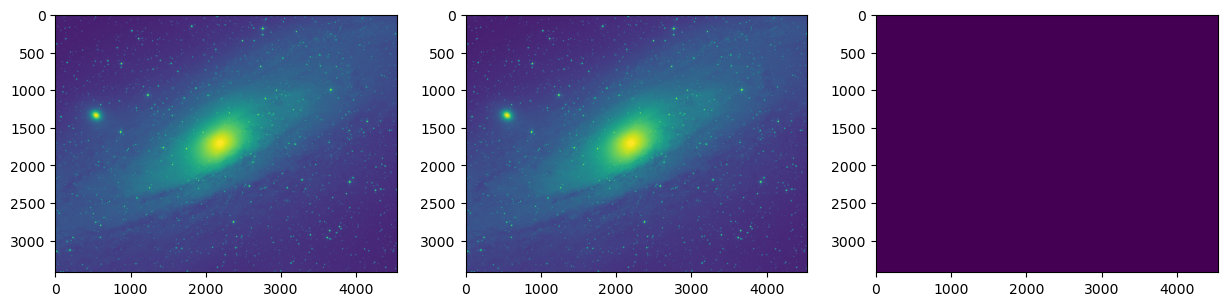

In [3]:
import PIL
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

src_img = np.array(PIL.Image.open(in_path))

img_w, img_h = sof.width, sof.height

img_stitched = np.zeros(src_img.shape)
for i in range(tiles_y):
    for j in range(tiles_x):
        idx = j + i * tiles_x
        img = np.array(PIL.Image.open(f"{out_prefix}_{idx}.jpg"))
        x_pos, y_pos = j * tile_step_x, i * tile_step_y
        new_w, new_h = tile_sizes[idx]
        img_stitched[y_pos:y_pos+new_h, x_pos:x_pos+new_w] = img[:new_h, :new_w]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(src_img)
axes[1].imshow(img_stitched.astype(np.uint8))
axes[2].imshow(src_img - img_stitched)
img_diff = src_img - img_stitched
print(f"Image min/max: {np.min(img_diff)} / {np.max(img_diff)}")

Image min/max: 0.0 / 0.0


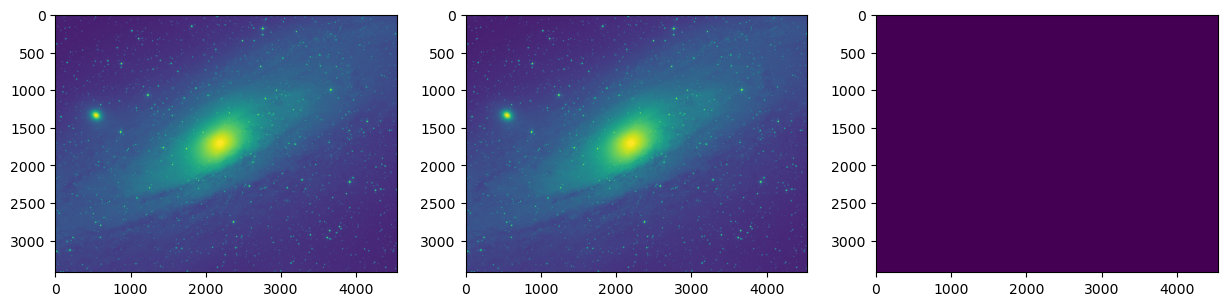

In [4]:
src_img = mpimg.imread(in_path)

img_stitched = np.zeros(src_img.shape)
for i in range(tiles_y):
    for j in range(tiles_x):
        idx = j + i * tiles_x
        img = mpimg.imread(f"{out_prefix}_{idx}.jpg")
        x_pos, y_pos = j * tile_step_x, i * tile_step_y
        new_w, new_h = tile_sizes[idx]
        img_stitched[y_pos:y_pos+new_h, x_pos:x_pos+new_w] = img[:new_h, :new_w]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(src_img)
axes[1].imshow(img_stitched.astype(np.uint8))
axes[2].imshow(src_img - img_stitched)
img_diff = src_img - img_stitched
print(f"Image min/max: {np.min(img_diff)} / {np.max(img_diff)}")